# Clasificación con Árbol de Decisión CART 



El dataset Sonar contiene mediciones de señales acústicas usadas para distinguir entre minas y rocas. 


## 1. Importación de bibliotecas


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
#GrisSearchCV buscar automáticamente la mejor combinación de hiperparámetros del modelo.
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold #Sirve para eliminar variables que casi no cambian
from sklearn.preprocessing import StandardScaler #estandarizar las variables numéricas. z=(x−μ​)/σ
from sklearn.decomposition import PCA #reducir la cantidad de variables manteniendo la mayor cantidad posible de información
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)


## 2. Configuración inicial

Se crean los nombres de las 60 variables predictoras del dataset Sonar.


In [2]:
semilla = 123

sns.set_theme(style="whitegrid", context="notebook")

nombres_variables = [f"variable_{numero:02d}" for numero in range(1, 61)]
nombre_clase = "clase"

url_datos = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "undocumented/connectionist-bench/sonar/sonar.all-data"
)


## 3. Carga del dataset Sonar

El dataset Sonar contiene mediciones de señales de sonar.

Cada fila representa una observación y cada columna numérica representa una característica de la señal.
Las 60 variables numéricas representan qué tan fuerte regresó esa señal en diferentes bandas de frecuencia. 
Cada fila del dataset es una especie de “huella acústica” del objeto
La última columna indica la clase:

- `M`: Mina
- `R`: Roca


In [3]:
datos_sonar = pd.read_csv(
    url_datos,
    header=None,
    names=nombres_variables + [nombre_clase]
)

datos_sonar.head()

,variable_01,variable_02,variable_03,variable_04,variable_05,variable_06,variable_07,variable_08,variable_09,variable_10,...,variable_52,variable_53,variable_54,variable_55,variable_56,variable_57,variable_58,variable_59,variable_60,clase
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [4]:
datos_sonar.columns

Index(['variable_01', 'variable_02', 'variable_03', 'variable_04',
       'variable_05', 'variable_06', 'variable_07', 'variable_08',
       'variable_09', 'variable_10', 'variable_11', 'variable_12',
       'variable_13', 'variable_14', 'variable_15', 'variable_16',
       'variable_17', 'variable_18', 'variable_19', 'variable_20',
       'variable_21', 'variable_22', 'variable_23', 'variable_24',
       'variable_25', 'variable_26', 'variable_27', 'variable_28',
       'variable_29', 'variable_30', 'variable_31', 'variable_32',
       'variable_33', 'variable_34', 'variable_35', 'variable_36',
       'variable_37', 'variable_38', 'variable_39', 'variable_40',
       'variable_41', 'variable_42', 'variable_43', 'variable_44',
       'variable_45', 'variable_46', 'variable_47', 'variable_48',
       'variable_49', 'variable_50', 'variable_51', 'variable_52',
       'variable_53', 'variable_54', 'variable_55', 'variable_56',
       'variable_57', 'variable_58', 'variable_59', 'variable_

In [5]:
datos_sonar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   variable_01  208 non-null    float64
 1   variable_02  208 non-null    float64
 2   variable_03  208 non-null    float64
 3   variable_04  208 non-null    float64
 4   variable_05  208 non-null    float64
 5   variable_06  208 non-null    float64
 6   variable_07  208 non-null    float64
 7   variable_08  208 non-null    float64
 8   variable_09  208 non-null    float64
 9   variable_10  208 non-null    float64
 10  variable_11  208 non-null    float64
 11  variable_12  208 non-null    float64
 12  variable_13  208 non-null    float64
 13  variable_14  208 non-null    float64
 14  variable_15  208 non-null    float64
 15  variable_16  208 non-null    float64
 16  variable_17  208 non-null    float64
 17  variable_18  208 non-null    float64
 18  variable_19  208 non-null    float64
 19  variable

## 4. Exploración inicial de los datos



Dimensiones del dataset:
(208, 61)

Tipos de datos:
float64    60
object      1
Name: count, dtype: int64

Distribución de clases:
clase
M    111
R     97
Name: count, dtype: int64

Proporción de clases:
clase
M    0.533654
R    0.466346
Name: proportion, dtype: float64


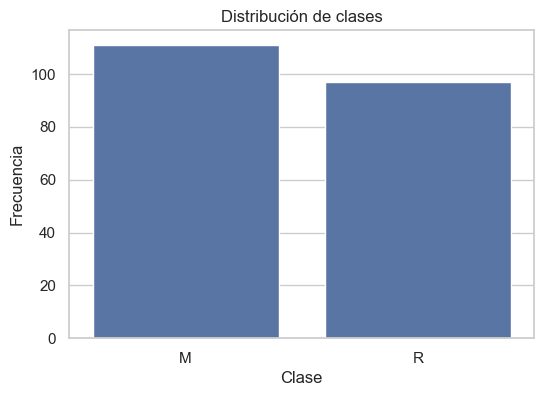

,count,mean,std,min,25%,50%,75%,max
variable_01,208.0,0.029164,0.022991,0.0015,0.013350,0.02280,0.035550,0.1371
variable_02,208.0,0.038437,0.032960,0.0006,0.016450,0.03080,0.047950,0.2339
variable_03,208.0,0.043832,0.038428,0.0015,0.018950,0.03430,0.057950,0.3059
variable_04,208.0,0.053892,0.046528,0.0058,0.024375,0.04405,0.064500,0.4264
variable_05,208.0,0.075202,0.055552,0.0067,0.038050,0.06250,0.100275,0.4010
variable_06,208.0,0.104570,0.059105,0.0102,0.067025,0.09215,0.134125,0.3823
variable_07,208.0,0.121747,0.061788,0.0033,0.080900,0.10695,0.154000,0.3729
variable_08,208.0,0.134799,0.085152,0.0055,0.080425,0.11210,0.169600,0.4590
variable_09,208.0,0.178003,0.118387,0.0075,0.097025,0.15225,0.233425,0.6828
variable_10,208.0,0.208259,0.134416,0.0113,0.111275,0.18240,0.268700,0.7106


In [6]:
print("Dimensiones del dataset:")
print(datos_sonar.shape)

print("\nTipos de datos:")
print(datos_sonar.dtypes.value_counts())

print("\nDistribución de clases:")
print(datos_sonar[nombre_clase].value_counts())

print("\nProporción de clases:")
print(datos_sonar[nombre_clase].value_counts(normalize=True)) #normalize=True indica que vez de mostrar cantidades absolutas, muestre proporciones

plt.figure(figsize=(6, 4))
"""
countplot: Función para contar automáticamente cuántas observaciones hay en cada categoría de una variable.
"""
sns.countplot(
    data=datos_sonar,
    x=nombre_clase,
    order=datos_sonar[nombre_clase].value_counts().index
)
plt.xlabel("Clase")
plt.ylabel("Frecuencia")
plt.title("Distribución de clases")
plt.show()

datos_sonar[nombres_variables].describe().T.head(10)


## 5. Separación entre variables predictoras y variable objetivo

Las variables predictoras son las 60 mediciones del sonar.

La variable objetivo es la columna original `clase`.

Las etiquetas originales del dataset son:

- `M`: mina.
- `R`: roca.

En esta versión no se crea una columna traducida ni una columna binaria adicional.


In [7]:
variables_predictoras = datos_sonar[nombres_variables]
variable_objetivo = datos_sonar[nombre_clase]

print("Primeras filas de las variables predictoras:")
display(variables_predictoras.head())

print("\nPrimeros valores de la variable objetivo:")
display(variable_objetivo.head())


Primeras filas de las variables predictoras:


,variable_01,variable_02,variable_03,variable_04,variable_05,variable_06,variable_07,variable_08,variable_09,variable_10,...,variable_51,variable_52,variable_53,variable_54,variable_55,variable_56,variable_57,variable_58,variable_59,variable_60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0232,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0125,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0033,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0241,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0156,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094



Primeros valores de la variable objetivo:


0    R
1    R
2    R
3    R
4    R
Name: clase, dtype: object

## 6. División en entrenamiento y prueba

Se tienen

- **80% entrenamiento**
- **20% prueba**

Se usa `stratify=variable_objetivo` para mantener una proporción similar de minas y rocas en ambos conjuntos.


In [8]:
variables_entrenamiento, variables_prueba, objetivo_entrenamiento, objetivo_prueba = train_test_split(
    variables_predictoras,
    variable_objetivo,
    test_size=0.20,
    random_state=semilla,
    stratify=variable_objetivo #Se mantiene la misma proporción de clases en los datos de entrenamiento y en los datos de prueba.
)

print("Tamaño de entrenamiento:")
print(variables_entrenamiento.shape)

print("\nTamaño de prueba:")
print(variables_prueba.shape)

print("\nProporción de clases en entrenamiento:")
print(objetivo_entrenamiento.value_counts(normalize=True))

print("\nProporción de clases en prueba:")
print(objetivo_prueba.value_counts(normalize=True))

Tamaño de entrenamiento:
(166, 60)

Tamaño de prueba:
(42, 60)

Proporción de clases en entrenamiento:
clase
M    0.536145
R    0.463855
Name: proportion, dtype: float64

Proporción de clases en prueba:
clase
M    0.52381
R    0.47619
Name: proportion, dtype: float64


## 7. Validación cruzada estratificada

Se usa validación cruzada de 5 particiones.

Esto significa que el modelo se entrena y valida varias veces usando diferentes subconjuntos del conjunto de entrenamiento.

La validación es estratificada, por lo que intenta mantener la proporción de clases en cada partición.

Además, definimos una función de puntuación para calcular AUC (Area Under the Curve) usando `M` como clase positiva sin crear una variable binaria permanente en el dataset.


In [9]:
validacion_cruzada = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=semilla
)

validacion_cruzada


StratifiedKFold(n_splits=5, random_state=123, shuffle=True)

In [10]:
def calcular_auc_mina(modelo, variables, objetivo):
    """
        1. El modelo calcula probabilidades para cada clase.
        2. Se identifica cuál columna corresponde a la clase "M".
        3. Se convierte el objetivo real en binario: Mina = 1, Roca = 0.
        4. Se calcula el AUC usando las probabilidades de Mina.
    """
    probabilidades = modelo.predict_proba(variables)
    indice_mina = list(modelo.classes_).index("M")
    objetivo_mina = (objetivo == "M").astype(int)
    return roc_auc_score(objetivo_mina, probabilidades[:, indice_mina])

## 8. Modelo 1: Árbol de decisión 

El algoritmo usado es **CART** y el criterio de división es **Gini**.



In [11]:
"""
Eliminar variables con varianza cero usando VarianceThreshold()
Escalar los datos usando StandardScaler()
Entrenar el árbol de decisión usando DecisionTreeClassifier()
"""
modelo_arbol_defecto = Pipeline(steps=[
    ("filtro_varianza_cero", VarianceThreshold()),
    ("escalador", StandardScaler()),
    ("arbol", DecisionTreeClassifier(
        criterion="gini",
        random_state=semilla
    ))
])

modelo_arbol_defecto.fit(variables_entrenamiento, objetivo_entrenamiento)

print("Modelo de árbol por defecto entrenado correctamente.")

modelo_arbol_defecto 

Modelo de árbol por defecto entrenado correctamente.


Pipeline(steps=[('filtro_varianza_cero', VarianceThreshold()),
                ('escalador', StandardScaler()),
                ('arbol', DecisionTreeClassifier(random_state=123))])

In [12]:
arbol_entrenado = modelo_arbol_defecto.named_steps["arbol"]

print(arbol_entrenado)

DecisionTreeClassifier(random_state=123)


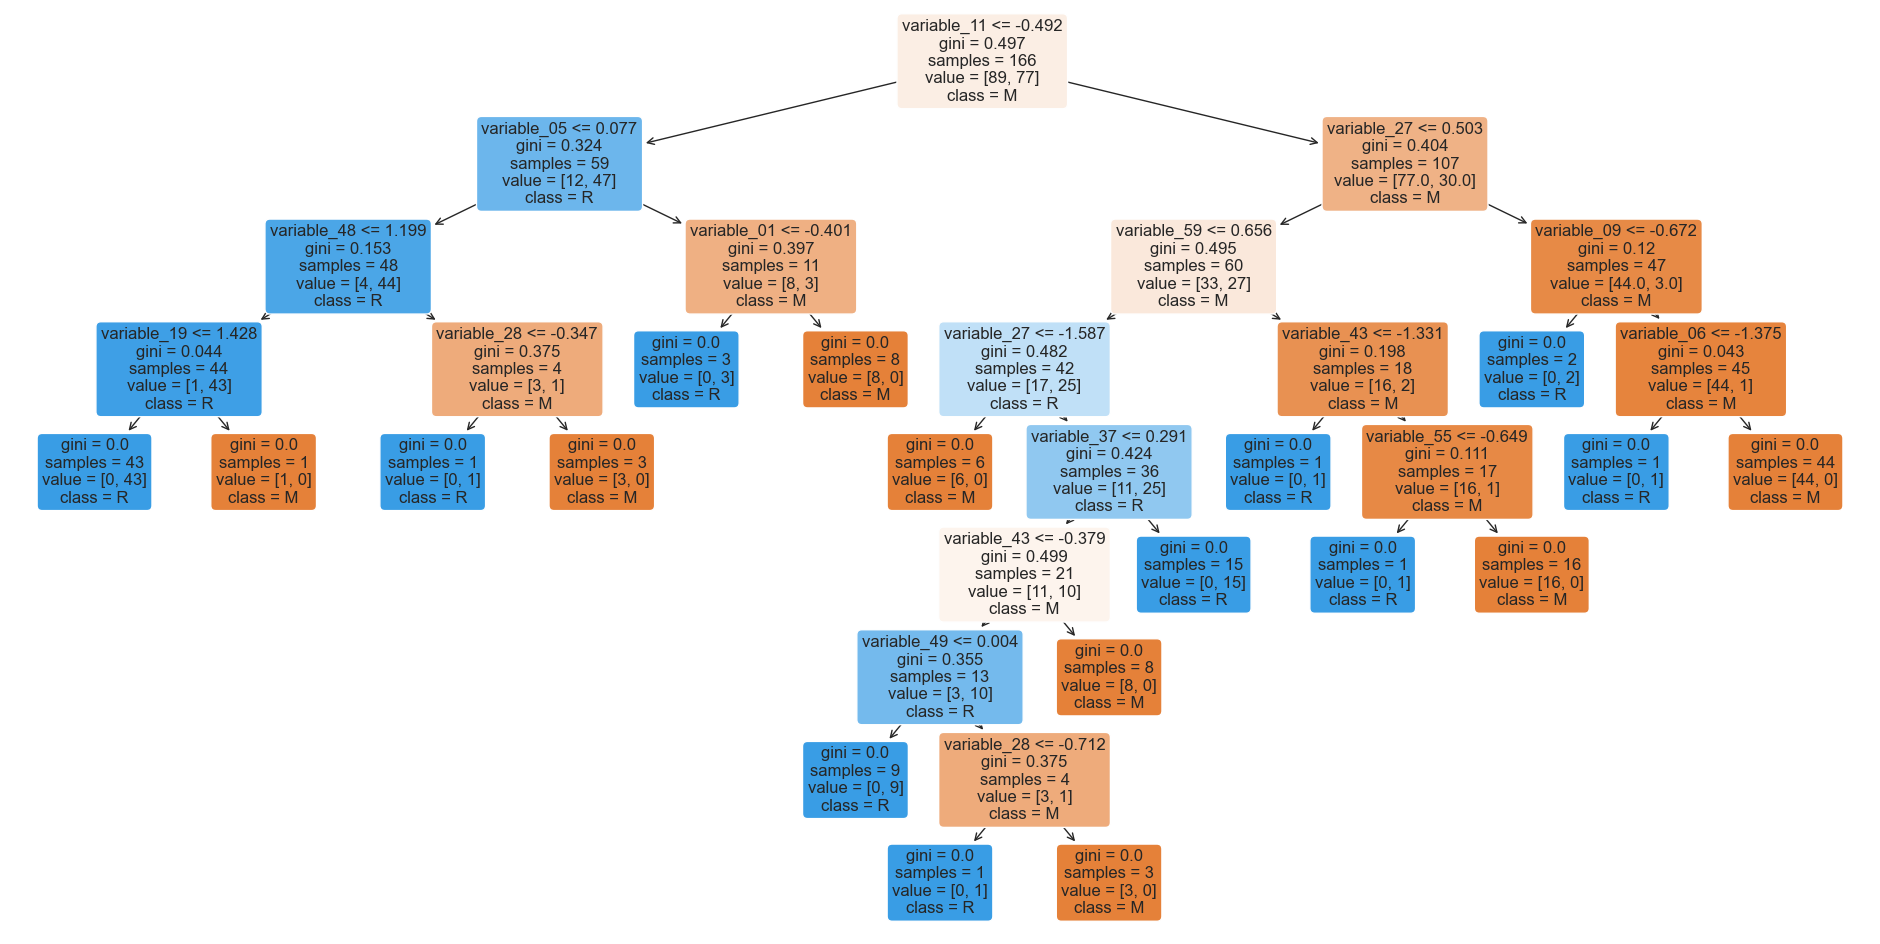

In [13]:

arbol_entrenado = modelo_arbol_defecto.named_steps["arbol"]

nombres_variables = variables_entrenamiento.columns
filtro_varianza = modelo_arbol_defecto.named_steps["filtro_varianza_cero"]
variables_seleccionadas = nombres_variables[filtro_varianza.get_support()].tolist()

plt.figure(figsize=(24, 12))

plot_tree(
    arbol_entrenado,
    feature_names=variables_seleccionadas,
    class_names=arbol_entrenado.classes_,
    filled=True,
    rounded=True,
    #max_depth=3,
    fontsize=12
)

plt.show()

## 9. Parámetro de poda del árbol

`DecisionTreeClassifier` usa un parámetro llamado `ccp_alpha`.

Este parámetro controla la poda del árbol:

- Valores pequeños permiten árboles más grandes.
- Valores grandes generan árboles más simples.


In [14]:
arbol_temporal = DecisionTreeClassifier(
    criterion="gini",
    random_state=semilla
)

arbol_temporal.fit(variables_entrenamiento, objetivo_entrenamiento)

ruta_poda = arbol_temporal.cost_complexity_pruning_path( #¿Qué ramas se podrían cortar?, ¿Qué valores de ccp_alpha permiten cortar esas ramas?
    variables_entrenamiento,
    objetivo_entrenamiento
)

valores_ccp_alpha = ruta_poda.ccp_alphas #Se devuelve los ccp_alphas efectivos y las impurezas correspondientes de los subárboles durante la poda por complejidad de coste
valores_ccp_alpha = valores_ccp_alpha[:-1]
valores_ccp_alpha = np.unique(valores_ccp_alpha)

if len(valores_ccp_alpha) > 20:
    indices = np.linspace(0, len(valores_ccp_alpha) - 1, 20).astype(int)
    valores_ccp_alpha = valores_ccp_alpha[indices]

print("Valores de ccp_alpha que se probarán:")
print(valores_ccp_alpha)

Valores de ccp_alpha que se probarán:
[0.         0.00903614 0.0107095  0.01177437 0.01178046 0.01876738
 0.02205702 0.02336619 0.02628697 0.0313709  0.03558042 0.04470888
 0.0473527 ]


## 10. Modelo 2: Árbol con búsqueda de `ccp_alpha`

Se busca el mejor valor de `ccp_alpha` usando validación cruzada.

La métrica utilizada es **AUC ROC**, calculada tomando `M` como clase positiva.


## Algoritmo de poda del árbol de decisión

La poda utilizada por `DecisionTreeClassifier` se conoce como **Minimal Cost-Complexity Pruning** o **poda por complejidad de coste**.

El objetivo de la poda es reducir el tamaño del árbol eliminando ramas que aportan poca mejora al modelo, pero aumentan su complejidad. Esto ayuda a evitar que el árbol memorice demasiado los datos de entrenamiento.

Cuando un árbol crece demasiado, puede ajustarse muy bien a los datos de entrenamiento, pero fallar con datos nuevos. A este problema se le conoce como **sobreajuste**.

### ¿Cómo funciona?

- Primero se entrena un árbol grande. Luego, el algoritmo revisa sus ramas y busca cuáles son las menos útiles. 
- Una rama se considera débil si reduce muy poco la impureza del árbol, pero añade varias hojas o divisiones.
- Si una rama complica mucho el árbol, pero mejora muy poco la clasificación, entonces puede ser podada.

### Algoritmo paso a paso

1. Se entrena un árbol de decisión completo o casi completo usando los datos de entrenamiento.

2. El algoritmo revisa cada nodo interno del árbol.

3. Para cada nodo interno, se analiza el subárbol que nace desde ese nodo.

4. El algoritmo compara dos opciones:

   - Mantener el subárbol completo.
   - Podar el subárbol y reemplazarlo por un solo nodo hoja.

5. Para cada subárbol, se calcula un valor llamado `ccp_alpha`.

Este valor mide cuánto empeoraría la impureza si se poda la rama, dividido entre la cantidad de hojas que se eliminan.

La fórmula es:

$$
\alpha = \frac{R(t) - R(T_t)}{\left|T_t\right| - 1}
$$

Donde:

- $R(t)$ es la impureza del nodo si se poda el subárbol.
- $R(T_t)$ es la impureza total del subárbol completo.
- $\left|T_t\right|$ es el número de hojas del subárbol.
- $\alpha$ es el valor efectivo de poda para ese subárbol.

6. El algoritmo identifica la rama con el menor valor de `ccp_alpha`.

7. Esa rama se considera la rama más débil, porque aporta poca mejora en comparación con la complejidad que añade.

8. El algoritmo poda esa rama.

9. Después vuelve a calcular los valores de `ccp_alpha` en el árbol podado.

10. El proceso se repite hasta que el árbol queda reducido a un nodo raíz o hasta que ya no hay más ramas que podar.

### Interpretación de `ccp_alpha`

El parámetro `ccp_alpha` controla el nivel de poda aplicado al árbol.

| Valor de `ccp_alpha` | Interpretación |
|---:|---|
| 0 | El árbol se mantiene grande, sin poda o casi sin poda |
| Bajo | Se eliminan pocas ramas |
| Medio | Se obtiene un árbol más equilibrado |
| Alto | Se eliminan muchas ramas |
| Muy alto | El árbol puede quedar demasiado simple |


In [15]:
modelo_arbol_base = Pipeline(steps=[
    ("filtro_varianza_cero", VarianceThreshold()),
    ("escalador", StandardScaler()),
    ("arbol", DecisionTreeClassifier(
        criterion="gini",
        random_state=semilla
    ))
])

rejilla_arbol = {
    "arbol__ccp_alpha": valores_ccp_alpha
}

busqueda_arbol = GridSearchCV(
    estimator=modelo_arbol_base,
    param_grid=rejilla_arbol,
    scoring=calcular_auc_mina,
    cv=validacion_cruzada,
    n_jobs=-1,
    return_train_score=True
)

busqueda_arbol.fit(variables_entrenamiento, objetivo_entrenamiento)

print("Mejor parámetro para el árbol sin PCA:")
print(busqueda_arbol.best_params_)

print("\nMejor AUC promedio en validación cruzada:")
print(busqueda_arbol.best_score_)

Mejor parámetro para el árbol sin PCA:
{'arbol__ccp_alpha': 0.02628696604600219}

Mejor AUC promedio en validación cruzada:
0.7025068082788671


## 11. Resultados de la búsqueda del árbol sin PCA

Creamos una tabla con los valores de `ccp_alpha` probados y su rendimiento promedio.


In [16]:
resultados_arbol = pd.DataFrame(busqueda_arbol.cv_results_)

columnas_resultados = [
    "param_arbol__ccp_alpha",
    "mean_test_score",
    "std_test_score",
    "mean_train_score"
]

tabla_resultados_arbol = resultados_arbol[columnas_resultados].sort_values(
    by="mean_test_score",
    ascending=False
)

tabla_resultados_arbol.head(10)

,param_arbol__ccp_alpha,mean_test_score,std_test_score,mean_train_score
8,0.026287,0.702507,0.079172,0.952091
5,0.018767,0.698504,0.106780,0.976613
7,0.023366,0.697692,0.086017,0.965362
0,0.0,0.696193,0.086058,1.000000
6,0.022057,0.689925,0.101147,0.970136
2,0.01071,0.688415,0.078778,0.998545
3,0.011774,0.688415,0.078778,0.998364
4,0.01178,0.688415,0.078778,0.998364
10,0.03558,0.687648,0.068697,0.914796
9,0.031371,0.686581,0.077877,0.932873


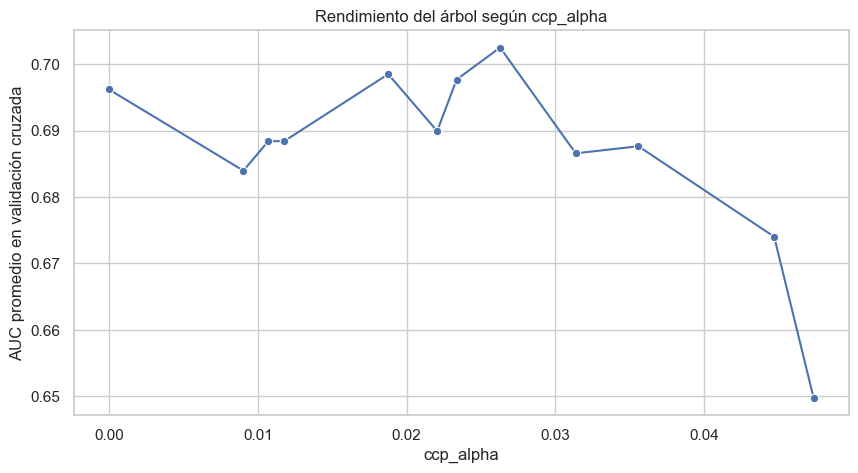

In [17]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=resultados_arbol.assign(
        ccp_alpha=resultados_arbol["param_arbol__ccp_alpha"].astype(float)
    ),
    x="ccp_alpha",
    y="mean_test_score",
    marker="o"
)

plt.xlabel("ccp_alpha")
plt.ylabel("AUC promedio en validación cruzada")
plt.title("Rendimiento del árbol según ccp_alpha")
plt.show()


## 12. Modelo 3: Árbol de decisión con PCA

Ahora agregamos PCA al pipeline.

PCA transforma las variables originales en componentes principales.

En este caso conservamos el 80% de la variabilidad de los datos.


In [18]:
modelo_arbol_pca = Pipeline(steps=[
    ("filtro_varianza_cero", VarianceThreshold()),
    ("escalador", StandardScaler()),
    ("pca", PCA(n_components=0.80, svd_solver="full")),
    ("arbol", DecisionTreeClassifier(
        criterion="gini",
        random_state=semilla
    ))
])

busqueda_arbol_pca = GridSearchCV(
    estimator=modelo_arbol_pca,
    param_grid=rejilla_arbol,
    scoring=calcular_auc_mina,
    cv=validacion_cruzada,
    n_jobs=-1,
    return_train_score=True
)

busqueda_arbol_pca.fit(variables_entrenamiento, objetivo_entrenamiento)

print("Mejor parámetro para el árbol con PCA:")
print(busqueda_arbol_pca.best_params_)

print("\nMejor AUC promedio en validación cruzada con PCA:")
print(busqueda_arbol_pca.best_score_)

numero_componentes = busqueda_arbol_pca.best_estimator_.named_steps["pca"].n_components_

print("\nNúmero de componentes principales usados por PCA:")
print(numero_componentes)

Mejor parámetro para el árbol con PCA:
{'arbol__ccp_alpha': 0.02205702241590473}

Mejor AUC promedio en validación cruzada con PCA:
0.7167796840958605

Número de componentes principales usados por PCA:
14


## 13. Modelo 4: Búsqueda manual alrededor del mejor valor de `ccp_alpha`

Se hace una segunda búsqueda más fina alrededor del mejor valor encontrado para el modelo con PCA.


In [19]:
mejor_ccp_alpha_pca = busqueda_arbol_pca.best_params_["arbol__ccp_alpha"]

if mejor_ccp_alpha_pca == 0:
    valores_ccp_alpha_manual = np.linspace(0.0, 0.05, 20)
else:
    limite_inferior = max(0.0, mejor_ccp_alpha_pca * 0.5)
    limite_superior = mejor_ccp_alpha_pca * 1.5
    valores_ccp_alpha_manual = np.linspace(limite_inferior, limite_superior, 20)

rejilla_arbol_manual = {
    "arbol__ccp_alpha": valores_ccp_alpha_manual
}

busqueda_arbol_pca_manual = GridSearchCV(
    estimator=modelo_arbol_pca,
    param_grid=rejilla_arbol_manual,
    scoring=calcular_auc_mina,
    cv=validacion_cruzada,
    n_jobs=-1,
    return_train_score=True
)

busqueda_arbol_pca_manual.fit(variables_entrenamiento, objetivo_entrenamiento)

print("Mejor parámetro para el árbol con PCA y búsqueda manual:")
print(busqueda_arbol_pca_manual.best_params_)

print("\nMejor AUC promedio en validación cruzada con PCA y búsqueda manual:")
print(busqueda_arbol_pca_manual.best_score_)

Mejor parámetro para el árbol con PCA y búsqueda manual:
{'arbol__ccp_alpha': 0.021476574457591446}

Mejor AUC promedio en validación cruzada con PCA y búsqueda manual:
0.7197426470588235


## 14. Función para evaluar modelos

Esta función evalúa cada modelo en el conjunto de prueba.

Calcula:

- Exactitud.
- AUC, usando `M` como clase positiva.
- Matriz de confusión.
- Reporte de clasificación.


In [20]:
def evaluar_modelo(nombre_modelo, modelo, variables_prueba, objetivo_prueba):
    predicciones = modelo.predict(variables_prueba)

    probabilidades = modelo.predict_proba(variables_prueba)
    indice_mina = list(modelo.classes_).index("M")
    probabilidades_mina = probabilidades[:, indice_mina]

    objetivo_mina = (objetivo_prueba == "M").astype(int)

    exactitud = accuracy_score(objetivo_prueba, predicciones)
    auc = roc_auc_score(objetivo_mina, probabilidades_mina)

    print("\n" + "=" * 70)
    print(nombre_modelo)
    print("=" * 70)

    print("\nExactitud:")
    print(exactitud)

    print("\nAUC:")
    print(auc)

    print("\nMatriz de confusión:")
    print(confusion_matrix(
        objetivo_prueba,
        predicciones,
        labels=["R", "M"]
    ))

    print("\nReporte de clasificación:")
    print(classification_report(
        objetivo_prueba,
        predicciones,
        labels=["R", "M"],
        target_names=["Roca", "Mina"]
    ))

    return {
        "modelo": nombre_modelo,
        "exactitud": exactitud,
        "auc": auc
    }


## 15. Evaluación de todos los modelos

Evaluamos los cuatro modelos:

1. Árbol por defecto.
2. Árbol con búsqueda de `ccp_alpha`.
3. Árbol con PCA.
4. Árbol con PCA y búsqueda manual.


In [21]:
resultados = []

resultados.append(evaluar_modelo(
    "Árbol por defecto",
    modelo_arbol_defecto,
    variables_prueba,
    objetivo_prueba
))

resultados.append(evaluar_modelo(
    "Árbol con búsqueda de ccp_alpha",
    busqueda_arbol.best_estimator_,
    variables_prueba,
    objetivo_prueba
))

resultados.append(evaluar_modelo(
    "Árbol con PCA",
    busqueda_arbol_pca.best_estimator_,
    variables_prueba,
    objetivo_prueba
))

resultados.append(evaluar_modelo(
    "Árbol con PCA y búsqueda manual",
    busqueda_arbol_pca_manual.best_estimator_,
    variables_prueba,
    objetivo_prueba
))

tabla_resultados = pd.DataFrame(resultados)
tabla_resultados = tabla_resultados.sort_values(by="auc", ascending=False)

tabla_resultados


Árbol por defecto

Exactitud:
0.8095238095238095

AUC:
0.8068181818181819

Matriz de confusión:
[[15  5]
 [ 3 19]]

Reporte de clasificación:
              precision    recall  f1-score   support

        Roca       0.83      0.75      0.79        20
        Mina       0.79      0.86      0.83        22

    accuracy                           0.81        42
   macro avg       0.81      0.81      0.81        42
weighted avg       0.81      0.81      0.81        42


Árbol con búsqueda de ccp_alpha

Exactitud:
0.8571428571428571

AUC:
0.8624999999999999

Matriz de confusión:
[[15  5]
 [ 1 21]]

Reporte de clasificación:
              precision    recall  f1-score   support

        Roca       0.94      0.75      0.83        20
        Mina       0.81      0.95      0.88        22

    accuracy                           0.86        42
   macro avg       0.87      0.85      0.85        42
weighted avg       0.87      0.86      0.86        42


Árbol con PCA

Exactitud:
0.6904761904761905


,modelo,exactitud,auc
1,Árbol con búsqueda de ccp_alpha,0.857143,0.862500
0,Árbol por defecto,0.809524,0.806818
2,Árbol con PCA,0.690476,0.801136
3,Árbol con PCA y búsqueda manual,0.690476,0.801136


## 16. Selección del mejor modelo

Se selecciona modelo aquel que tenga mayor AUC en el conjunto de prueba.
En este experimento, el uso de PCA no mejoró el desempeño del árbol de decisión. El árbol con PCA obtuvo una exactitud menor que el árbol sin PCA, lo que indica que la transformación de las variables originales en componentes principales pudo haber eliminado o mezclado información relevante para distinguir entre minas y rocas. 

El mejor resultado se obtuvo con el árbol de decisión optimizado mediante la búsqueda del parámetro ccp_alpha, por lo que este modelo se selecciona como la mejor alternativa.


In [22]:
mejor_nombre_modelo = tabla_resultados.iloc[0]["modelo"]

if mejor_nombre_modelo == "Árbol por defecto":
    mejor_modelo = modelo_arbol_defecto
elif mejor_nombre_modelo == "Árbol con búsqueda de ccp_alpha":
    mejor_modelo = busqueda_arbol.best_estimator_
elif mejor_nombre_modelo == "Árbol con PCA":
    mejor_modelo = busqueda_arbol_pca.best_estimator_
else:
    mejor_modelo = busqueda_arbol_pca_manual.best_estimator_

print("Mejor modelo seleccionado:")
print(mejor_nombre_modelo)

Mejor modelo seleccionado:
Árbol con búsqueda de ccp_alpha


## 17. Matriz de confusión del mejor modelo

La matriz de confusión permite observar cuántas observaciones fueron clasificadas correctamente e incorrectamente.

Filas: clase real.

Columnas: clase predicha.


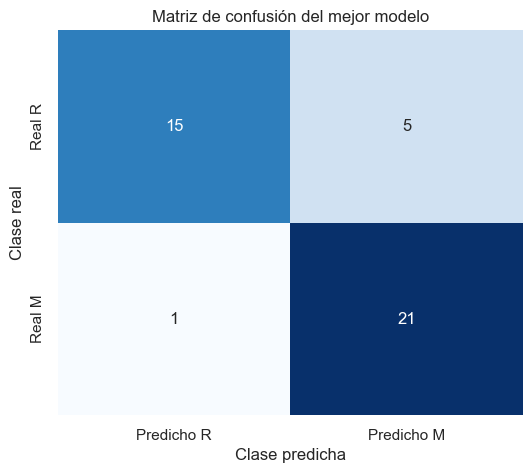

In [23]:
predicciones_mejor_modelo = mejor_modelo.predict(variables_prueba)

matriz_confusion = confusion_matrix(
    objetivo_prueba,
    predicciones_mejor_modelo,
    labels=["R", "M"]
)

tabla_matriz_confusion = pd.DataFrame(
    matriz_confusion,
    index=["Real R", "Real M"],
    columns=["Predicho R", "Predicho M"]
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    tabla_matriz_confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.title("Matriz de confusión del mejor modelo")
plt.show()


- 15 rocas fueron clasificadas correctamente como rocas.
- 5 rocas fueron clasificadas incorrectamente como minas.
- 1 mina fue clasificada incorrectamente como roca.
- 21 minas fueron clasificadas correctamente como minas.

## 18. Curva ROC del mejor modelo

La curva ROC muestra la capacidad del modelo para separar las dos clases.

En esta visualización se usa `M` como clase positiva.

Un AUC más alto indica mejor capacidad de discriminación entre roca y mina.


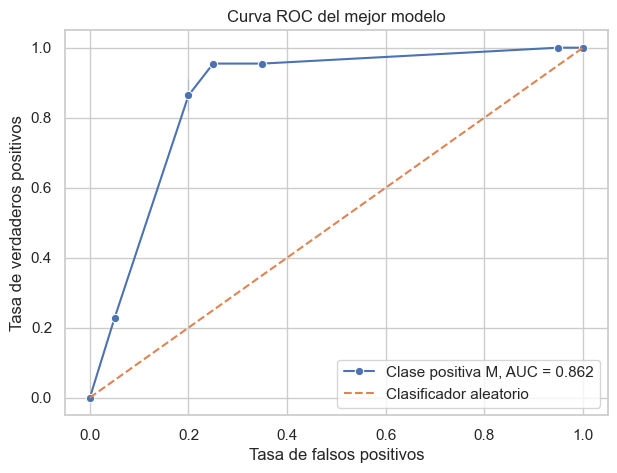

AUC: 0.8625


In [24]:
# Obtener el mejor modelo
mejor_modelo_final = mejor_modelo

# Identificar la posición de la clase positiva: Mina
indice_clase_mina = list(mejor_modelo_final.classes_).index("M")

# Obtener las probabilidades predichas para la clase Mina
probabilidades_mina = mejor_modelo_final.predict_proba(variables_prueba)[:, indice_clase_mina]

# Convertir la variable objetivo a formato binario
# M = 1, R = 0
objetivo_prueba_mina = (objetivo_prueba == "M").astype(int)

# Calcular la curva ROC
tasa_falsos_positivos, tasa_verdaderos_positivos, umbrales = roc_curve(
    objetivo_prueba_mina,
    probabilidades_mina
)

# Calcular correctamente el AUC
auc_roc = roc_auc_score(
    objetivo_prueba_mina,
    probabilidades_mina
)

# Crear una tabla con los valores de la curva ROC
tabla_roc = pd.DataFrame({
    "tasa_falsos_positivos": tasa_falsos_positivos,
    "tasa_verdaderos_positivos": tasa_verdaderos_positivos
})

# Graficar la curva ROC
plt.figure(figsize=(7, 5))

sns.lineplot(
    data=tabla_roc,
    x="tasa_falsos_positivos",
    y="tasa_verdaderos_positivos",
    marker="o",
    label=f"Clase positiva M, AUC = {auc_roc:.3f}"
)

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    label="Clasificador aleatorio"
)

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC del mejor modelo")
plt.legend()
plt.show()

print(f"AUC: {auc_roc:.4f}")

Si se toma una mina y una roca al azar,
el modelo tiene ~86% de probabilidad de asignar mayor probabilidad a la mina correcta.

## 19. Importancia de variables del árbol sin PCA

El modelo sin PCA es más interpretable, ya que sus divisiones usan las variables originales del dataset.


In [25]:
mejor_arbol_sin_pca = busqueda_arbol.best_estimator_

filtro_varianza = mejor_arbol_sin_pca.named_steps["filtro_varianza_cero"]
arbol_final_sin_pca = mejor_arbol_sin_pca.named_steps["arbol"]

nombres_variables_filtradas = variables_entrenamiento.columns[
    filtro_varianza.get_support()
]

tabla_importancia = pd.DataFrame({
    "variable": nombres_variables_filtradas,
    "importancia": arbol_final_sin_pca.feature_importances_
})

tabla_importancia = tabla_importancia.sort_values(
    by="importancia",
    ascending=False
)

tabla_importancia.head(15)

,variable,importancia
10,variable_11,0.355108
26,variable_27,0.224607
4,variable_05,0.130019
58,variable_59,0.103473
42,variable_43,0.102675
36,variable_37,0.084118
0,variable_01,0.000000
39,variable_40,0.000000
43,variable_44,0.000000
41,variable_42,0.000000


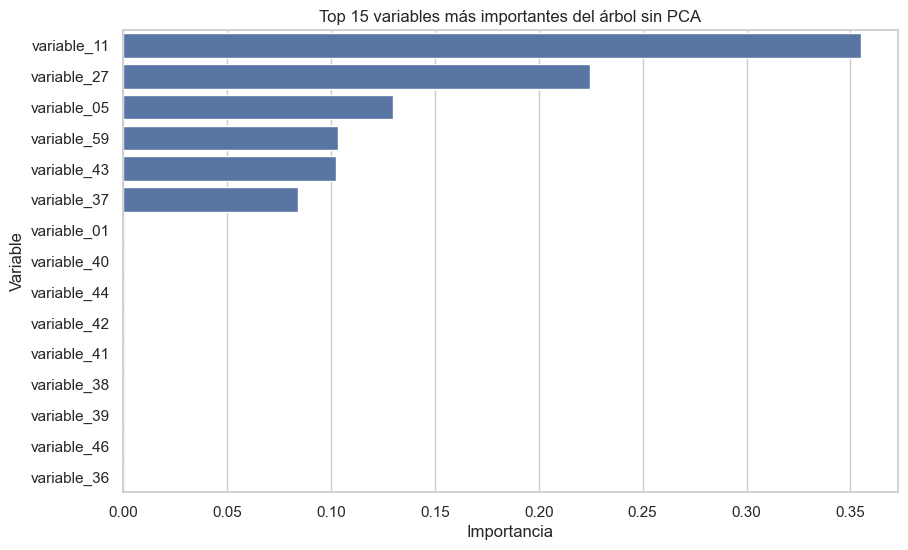

In [26]:
tabla_importancia_top = tabla_importancia.head(15).copy()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=tabla_importancia_top,
    x="importancia",
    y="variable"
)

plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Top 15 variables más importantes del árbol sin PCA")
plt.show()


## 20. Visualización del árbol sin PCA

Este árbol es el más fácil de explicar porque usa las variables originales.

Cada nodo muestra una condición de división, por ejemplo:

`variable_11 <= 0.25`

Eso significa que el algoritmo separa los datos dependiendo de si se cumple o no esa condición.


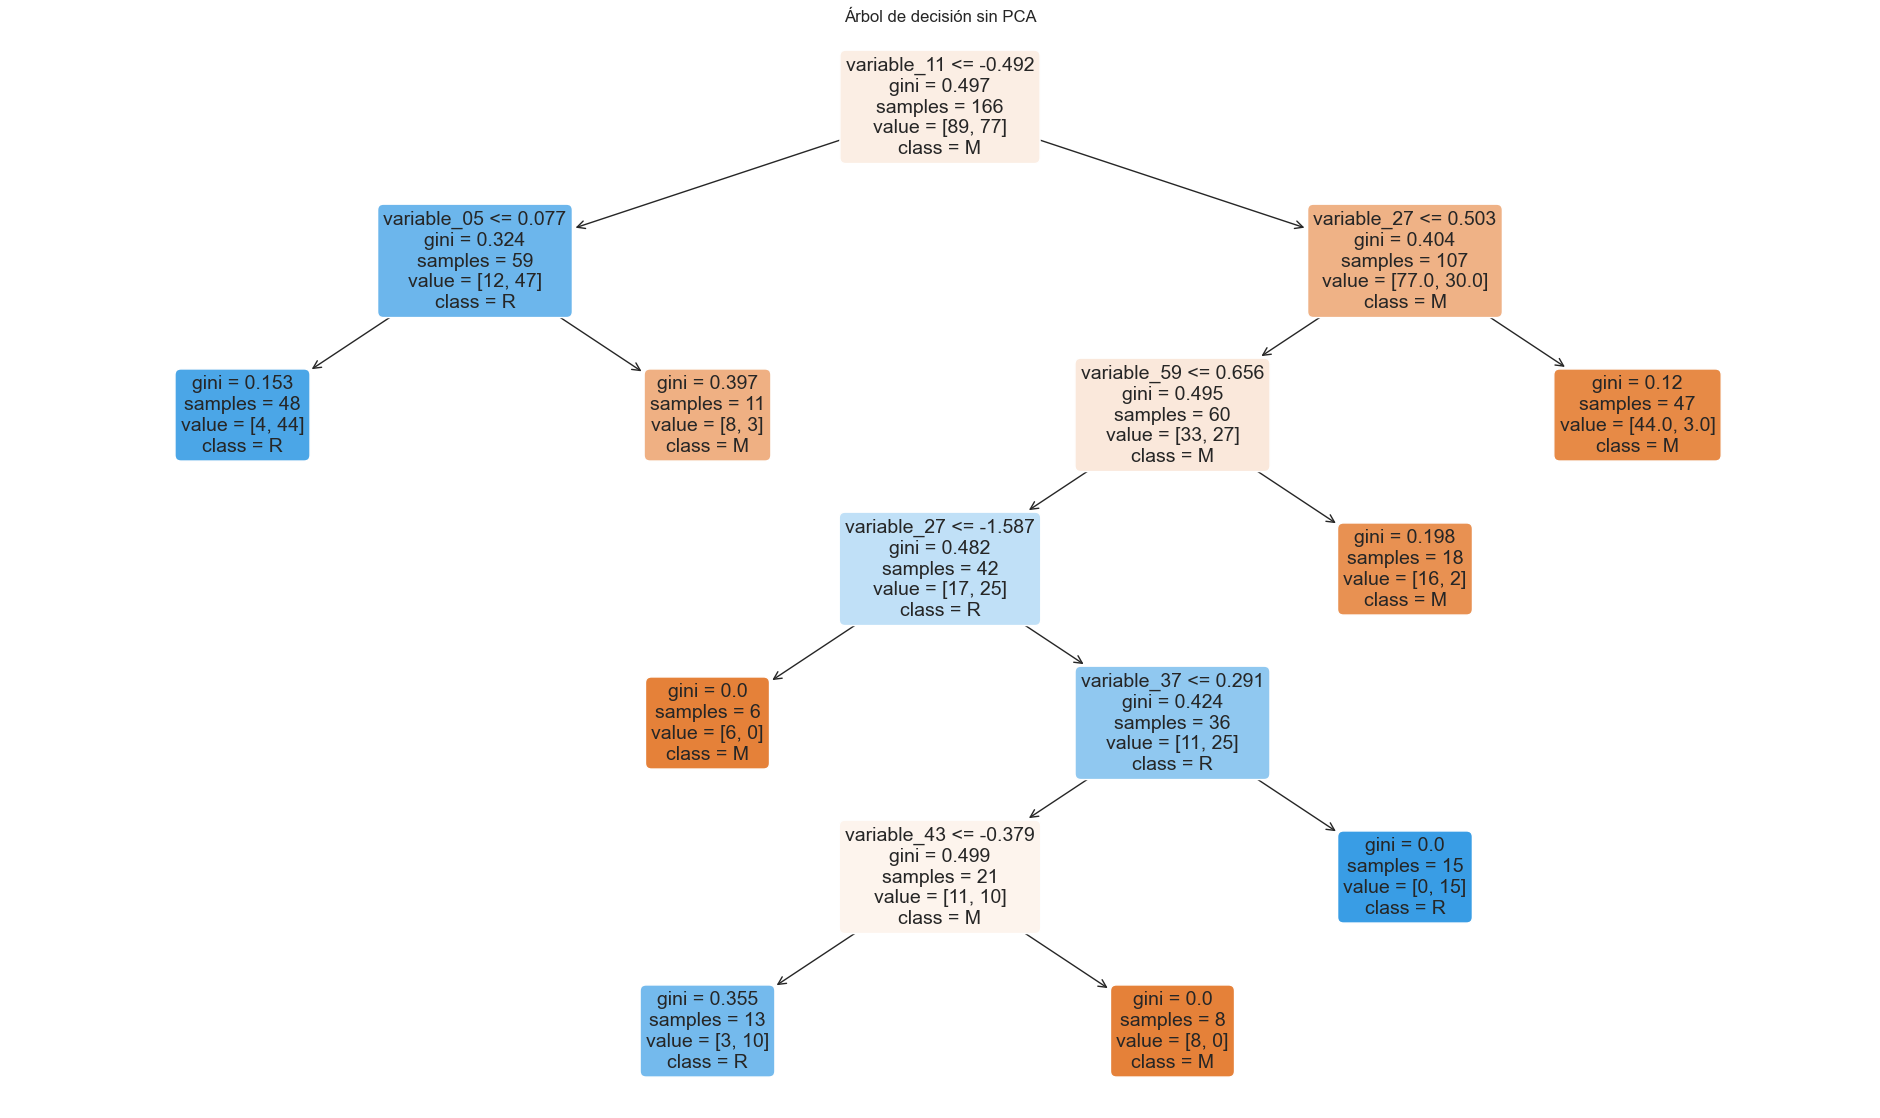

In [27]:
plt.figure(figsize=(24, 14))

plot_tree(
    arbol_final_sin_pca,
    feature_names=list(nombres_variables_filtradas),
    class_names=["M", "R"],
    filled=True,
    rounded=True,
    fontsize=14
)

plt.title("Árbol de decisión sin PCA")
plt.show()

## 21. Reglas del árbol 

In [28]:
reglas_arbol = export_text(
    arbol_final_sin_pca,
    feature_names=list(nombres_variables_filtradas)
)

print(reglas_arbol)

|--- variable_11 <= -0.49
|   |--- variable_05 <= 0.08
|   |   |--- class: R
|   |--- variable_05 >  0.08
|   |   |--- class: M
|--- variable_11 >  -0.49
|   |--- variable_27 <= 0.50
|   |   |--- variable_59 <= 0.66
|   |   |   |--- variable_27 <= -1.59
|   |   |   |   |--- class: M
|   |   |   |--- variable_27 >  -1.59
|   |   |   |   |--- variable_37 <= 0.29
|   |   |   |   |   |--- variable_43 <= -0.38
|   |   |   |   |   |   |--- class: R
|   |   |   |   |   |--- variable_43 >  -0.38
|   |   |   |   |   |   |--- class: M
|   |   |   |   |--- variable_37 >  0.29
|   |   |   |   |   |--- class: R
|   |   |--- variable_59 >  0.66
|   |   |   |--- class: M
|   |--- variable_27 >  0.50
|   |   |--- class: M



## Reglas del árbol de decisión

El árbol clasifica cada registro siguiendo condiciones desde la raíz hasta una hoja final.

### Reglas obtenidas

1. Si `variable_11 <= -0.49` y `variable_05 <= 0.08`, entonces:

   **Clase predicha: Roca**

2. Si `variable_11 <= -0.49` y `variable_05 > 0.08`, entonces:

   **Clase predicha: Mina**

3. Si `variable_11 > -0.49` y `variable_27 > 0.50`, entonces:

   **Clase predicha: Mina**

4. Si `variable_11 > -0.49`, `variable_27 <= 0.50` y `variable_59 > 0.66`, entonces:

   **Clase predicha: Mina**

5. Si `variable_11 > -0.49`, `variable_27 <= 0.50`, `variable_59 <= 0.66` y `variable_27 <= -1.59`, entonces:

   **Clase predicha: Mina**

6. Si `variable_11 > -0.49`, `variable_27 <= 0.50`, `variable_59 <= 0.66`, `variable_27 > -1.59`, `variable_37 <= 0.29` y `variable_43 <= -0.38`, entonces:

   **Clase predicha: Roca**

7. Si `variable_11 > -0.49`, `variable_27 <= 0.50`, `variable_59 <= 0.66`, `variable_27 > -1.59`, `variable_37 <= 0.29` y `variable_43 > -0.38`, entonces:

   **Clase predicha: Mina**

8. Si `variable_11 > -0.49`, `variable_27 <= 0.50`, `variable_59 <= 0.66`, `variable_27 > -1.59` y `variable_37 > 0.29`, entonces:

   **Clase predicha: Roca**



El árbol comienza dividiendo los registros con `variable_11`. Después utiliza otras variables, como `variable_05`, `variable_27`, `variable_59`, `variable_37` y `variable_43`, para tomar decisiones más específicas.

Cada regla representa un camino completo desde la raíz del árbol hasta una hoja final. La clase final puede ser `Roca` o `Mina`.

## 22. Visualización del árbol con PCA

Este árbol puede ser útil para comparar rendimiento, pero es menos interpretable.

En lugar de usar variables originales, usa componentes principales:

- `componente_principal_1`
- `componente_principal_2`
- etc.


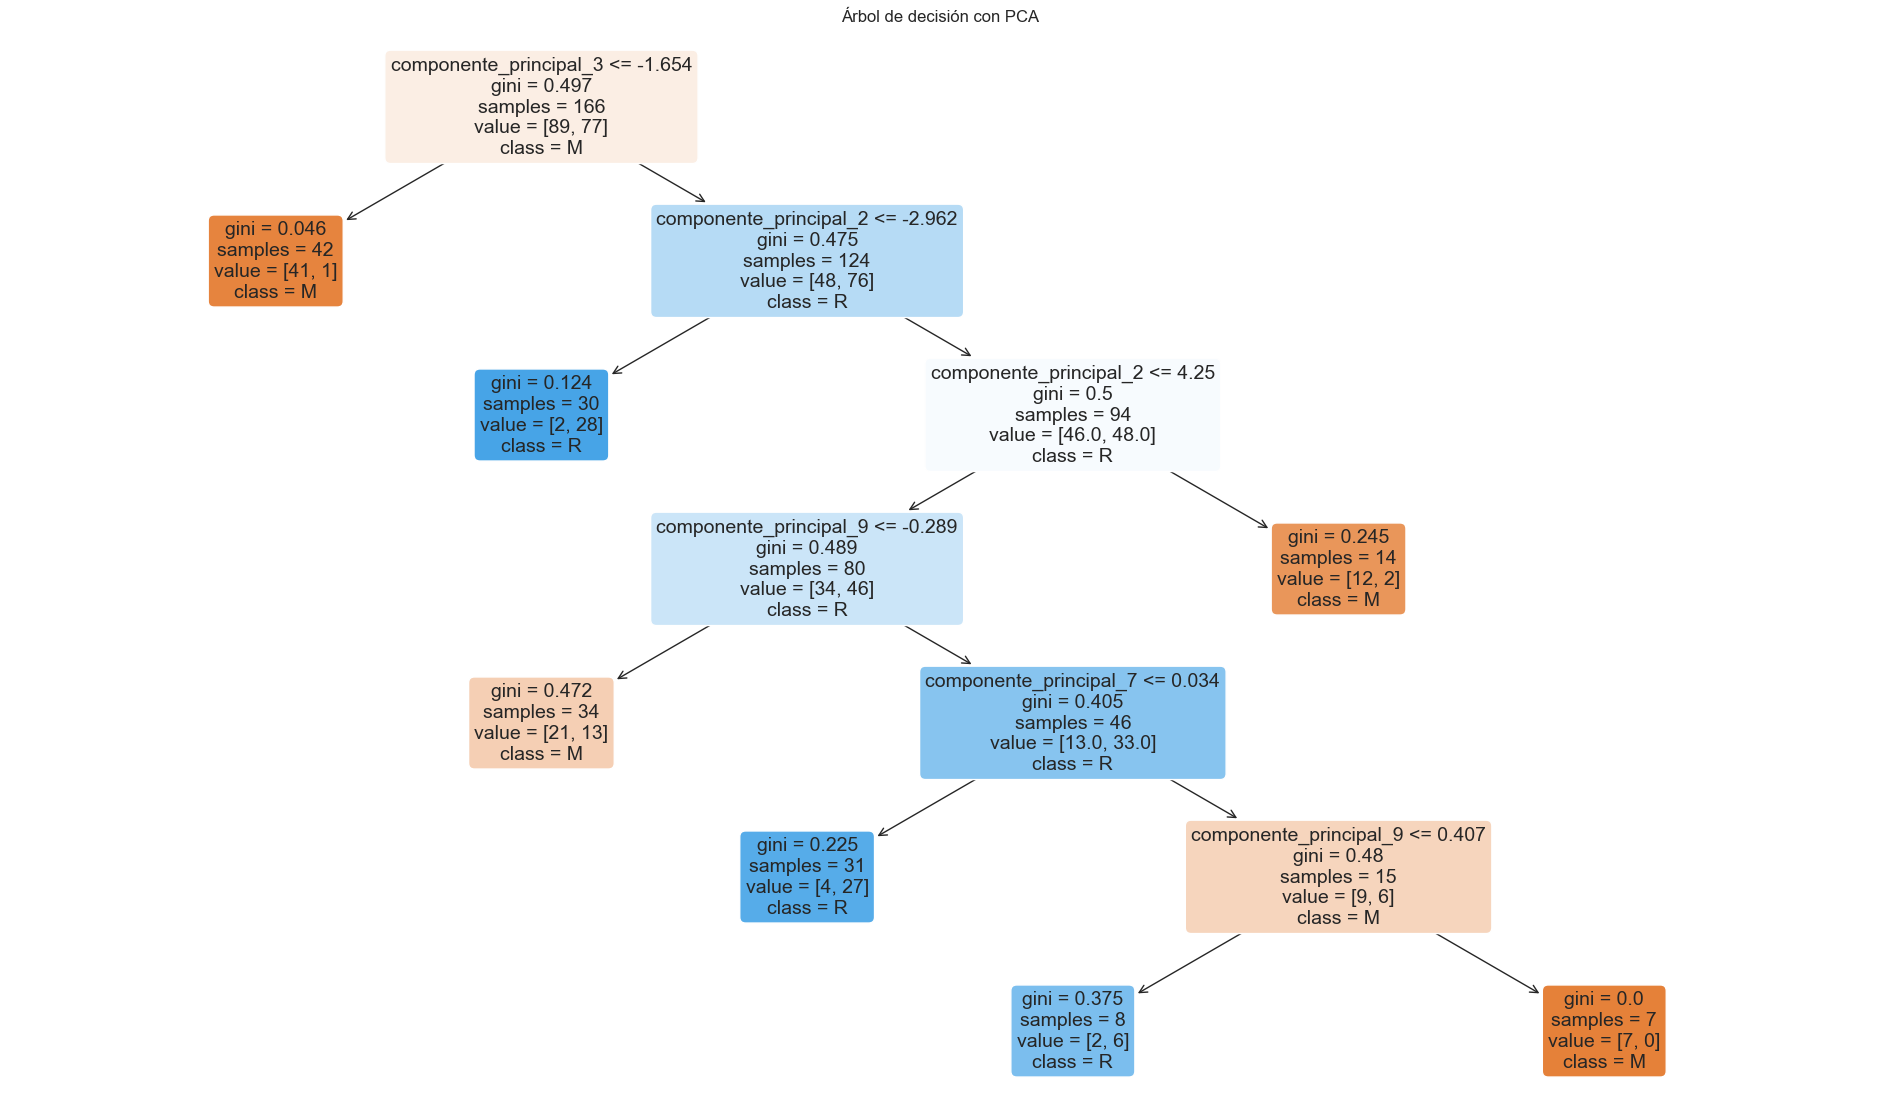

In [29]:
mejor_arbol_con_pca = busqueda_arbol_pca.best_estimator_

arbol_final_con_pca = mejor_arbol_con_pca.named_steps["arbol"]
pca_final = mejor_arbol_con_pca.named_steps["pca"]

nombres_componentes = [
    f"componente_principal_{numero + 1}"
    for numero in range(pca_final.n_components_)
]

plt.figure(figsize=(24, 14))

plot_tree(
    arbol_final_con_pca,
    feature_names=nombres_componentes,
    class_names=["M", "R"],
    filled=True,
    rounded=True,
    fontsize=14
)

plt.title("Árbol de decisión con PCA")
plt.show()

## Ejercicio

 - Cambia el  criterion="gini" por criterion="entropy".
 -Investigar cuales criterios son aceptables en la bilvioteca
-  Prueba diferentes valores de max_depth.
- Prueba con el 70% del dataset para entrenamiento y 30% para pruebas ¿Cambian los resultados?
- Compara los modelos usando accuracy, recall, precision, F1-score y AUC.
- Explicar cuál modelo elegirían y por qué.

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

https://archive.ics.uci.edu/dataset/151/connectionist+bench+sonar+mines+vs+rocks